In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import logging
logging.basicConfig(level=logging.INFO)

## Simulating ZTF SN Ia
This notebook simulates SN Ia light curves with realistic cadence, rate, parameter distributions, etc

In [3]:
quick_test = False
NSIM = 3000
RANDSEED = 1024

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Circle
from scipy.interpolate import interp1d
import pandas as pd
import sncosmo
from scipy import stats
from scipy.special import expit
from nested_pandas import read_parquet
from joblib import Parallel, delayed
import cloudpickle as pickle
from regions import RectangleSkyRegion
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.time import Time
import inspect
from IPython.display import display, Markdown

from lightcurvelynx.obstable.ztf_obstable import ZTFObsTable
from lightcurvelynx.astro_utils.passbands import PassbandGroup
from lightcurvelynx.astro_utils.pzflow_node import PZFlowNode
from lightcurvelynx.astro_utils.snia_utils import (
    DistModFromRedshift,
    HostmassX1Func,
    X0FromDistMod,
    num_snia_per_redshift_bin,
    SNCoordGivenPhysicalSep,
    snia_volumetric_rates,
)
from lightcurvelynx.math_nodes.scipy_random import SamplePDF
from lightcurvelynx.math_nodes.np_random import NumpyRandomFunc
from lightcurvelynx.simulate import simulate_lightcurves
from lightcurvelynx.models.sncosmo_models import SncosmoWrapperModel
from lightcurvelynx.models.snia_host import SNIaHost
from lightcurvelynx.utils.plotting import plot_lightcurves
from lightcurvelynx.math_nodes.ra_dec_sampler import ObsTableUniformRADECSampler
from lightcurvelynx.astro_utils.dustmap import DustmapWrapper,SFDMap
from lightcurvelynx.effects.extinction import ExtinctionEffect
from lightcurvelynx.astro_utils.mag_flux import mag2flux,flux2mag
from lightcurvelynx.astro_utils.detector_footprint import DetectorFootprint
from lightcurvelynx.utils.extrapolate import LinearDecayOnMag,ZeroPadding

from lightcurvelynx import _LIGHTCURVELYNX_BASE_DATA_DIR

from utils.lcfit import fit_single_lc
from utils.plotting_utils import plot_coverage_map
from utils.analysis_utils import lc_quality_cuts, spec_selection_func

from ztf_snia_sim_params import SIM_PARAMS

INFO:numexpr.utils:NumExpr defaulting to 10 threads.


In [5]:
RNG = np.random.default_rng(RANDSEED)

In [6]:
# load and define constants that are used throughout the simulations
H0 = SIM_PARAMS["H0"]
OMEGA_M = SIM_PARAMS["Omega_m"]
ALPHA = SIM_PARAMS["alpha"]
BETA = SIM_PARAMS["beta"]
ZMIN = SIM_PARAMS["zmin"]
ZMAX = SIM_PARAMS["zmax"]
MAGABS = SIM_PARAMS["mag_abs"]
SIGMA_MAGABS = SIM_PARAMS["sigma_mag_abs"]

ZP_ERR_MAG = SIM_PARAMS["zp_mag_err"]

In [7]:
%%time

obs_log = pd.read_parquet('data/ztf_observing_log_combined_w_metadata.parquet')
colmap = {"ra":"ra",
          "dec":"dec",
          "time":"mjd",
          "zp":"zp_nJy",
          "filter":"filter",
          "sky":"sky_adu_ztfsn",
         }

#ztf ccd size 6144 × 6160 pixel * 16
pixel_scale = 1.01 #arcsec/pixel
center = SkyCoord(ra=0.0, dec=0.0, unit="deg", frame="icrs")
rect_region = RectangleSkyRegion(center=center, width=7.323 * u.deg, 
                                 height=7.504 * u.deg, angle=0.0 * u.deg) # Dekany 2020 Table 3
ztf_fp = DetectorFootprint(rect_region, pixel_scale=pixel_scale)

ztf_obstable = ZTFObsTable(obs_log,colmap=colmap,detector_footprint=ztf_fp)
ztf_obstable.survey_values["zp_err_mag"] = ZP_ERR_MAG

t_min, t_max = ztf_obstable.time_bounds()
print(f"Loaded OpSim with {len(ztf_obstable)} rows and times [{t_min}, {t_max}]")

passband_group = PassbandGroup.from_preset(preset="ZTF", filters=["g", "r", "i"])
print(f"Loaded Passbands: {passband_group}")

INFO:lightcurvelynx.obstable.obs_table:Provided radius 3.868 is smaller than footprint radius 5.228687174015264. Using the footprint radius instead.
INFO:lightcurvelynx.astro_utils.passbands:Loading passbands from preset ZTF


Loaded OpSim with 522192 rows and times [58288.171875, 59273.55859375]
Loaded Passbands: PassbandGroup containing 3 passbands: ZTF_g, ZTF_r, ZTF_i
CPU times: user 570 ms, sys: 129 ms, total: 699 ms
Wall time: 756 ms


In [8]:
# #this is slow, so we only do it once, the total ZTF sky coverage given by the obstable is 
# sky_coverage = ztf_obstable.estimate_coverage(use_footprint=True,max_depth=12)
# print(f"The total sky coverage is {sky_coverage} square degrees")

In [9]:
sky_coverage = 32133. # deg^2
fill_factor = 0.867 # Dekany et al. 2020; the fill factor takes into account loss in ccd gaps
sky_coverage = sky_coverage * fill_factor

In [10]:
t = Time([t_min,t_max], format='mjd', scale='utc')
t.to_datetime()

array([datetime.datetime(2018, 6, 19, 4, 7, 30),
       datetime.datetime(2021, 2, 28, 13, 24, 22, 500000)], dtype=object)

In [11]:
ztf_obstable._table.columns

Index(['time', 'band', 'fieldid', 'fieldra', 'fielddec', 'rcid', 'maglimit',
       'zp_abmag', 'gain', 'expid', 'infobits', 'skynoise', 'filter',
       'exptime', 'fwhm', 'obsdate', 'scibckgnd', 'ra', 'dec', 'maglim',
       'airmass', 'zp', 'sky', 'sky_adu_ztfmeta', 'obsmjd'],
      dtype='object')

In [12]:
# Load the Flow model into a PZFlow node. This gives access to all of the outputs of the
# flow model as attributes of the PZFlowNode.
pz_node = PZFlowNode.from_file("data/ztfsniadr2_host_sn_before_selection_pzflow.pkl",  # filename
    node_label="pznode",
)
radec_node = ObsTableUniformRADECSampler(ztf_obstable, node_label="radec")

# Create a model for the host of the SNIa. The attributes will be sampled via
# the PZFlowNode's model. So each hos instantiation will have its own properties.
# Note: This requires the user to know the output names from the underlying flow model.

rate = lambda z: 2.35e-5 #(2.35 ± 0.24) × 10^4 Gpc^−3 yr^−1 = (2.35 ± 0.24) × 10^4 * 10^-9 Mpc^−3 yr^−1, from ZTF BTS paper Perley et al. 2020

nsn, z = num_snia_per_redshift_bin(ZMIN, ZMAX, 100, H0=H0, Omega_m=OMEGA_M, vol_rate_function=rate)
zpdf = interp1d(z, nsn, bounds_error=False, fill_value=0)

host = SNIaHost(
    ra = radec_node.ra,
    dec = radec_node.dec,
    hostmass=pz_node.mass,
    redshift=SamplePDF(zpdf),
    node_label="host",
)

INFO:2026-04-08 11:36:10,311:jax._src.xla_bridge:812: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/Users/mi/anaconda3/envs/lightcurvelynx/bin/../lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file)
INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/Users/mi/anaconda3/envs/lightcurvelynx/bin/../lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file)


In [13]:
distmod_func = DistModFromRedshift(host.redshift, H0=H0, Omega_m=OMEGA_M)

m_abs_func = NumpyRandomFunc("normal", loc=MAGABS, scale=SIGMA_MAGABS)

# we model host-sn separation as an exponential distribution based on Fig 3 of Gupta et al 2016, mean separation = 5kpc
physical_host_sn_sep = NumpyRandomFunc("exponential", scale = 5.)
sncoor_node = SNCoordGivenPhysicalSep(host.ra, host.dec, physical_host_sn_sep, host.redshift, H0=H0, Omega_m=OMEGA_M,node_label='sncoor_node')

x0_func = X0FromDistMod(
    distmod=distmod_func,
    x1=pz_node.x1,
    c=pz_node.c,
    alpha=ALPHA,
    beta=BETA,
    m_abs=m_abs_func,
    node_label="x0_func",
)

sncosmo_modelname = "salt3"
time_extrap_before = ZeroPadding()
time_extrap_after = LinearDecayOnMag(decay_rate=0.02, mag_thres=30.)
wave_extrap_before = ZeroPadding()
wave_extrap_after = ZeroPadding()
source = SncosmoWrapperModel(
    sncosmo_modelname,
    t0=NumpyRandomFunc("uniform", low=t_min, high=t_max),
    x0=x0_func,
    x1=pz_node.x1,
    c=pz_node.c,
    ra=sncoor_node.ra,
    dec=sncoor_node.dec,
    redshift=host.redshift,
    node_label="source",
    time_extrapolation=(time_extrap_before,time_extrap_after),
    wave_extrapolation=(wave_extrap_before,wave_extrap_after),    
)
    
mwextinction = SFDMap(
    ra=source.ra,
    dec=source.dec,
    node_label="mwext",
)

# Create an extinction effect using the EBVs from that dust map.
ext_effect = ExtinctionEffect(extinction_model="F99", ebv=mwextinction, 
                              r_v=3.1,frame='observer',backend="dust_extinction")
source.add_effect(ext_effect)


INFO:lightcurvelynx.astro_utils.dustmap:SFD dust map data files not found.
Attempting to download from: ('https://github.com/kbarbary/sfddata/archive/master.tar.gz',)
to the directory /Users/mi/Work/lightcurvelynx/lightcurvelynx/data/dustmaps/sfdmap2


In [14]:
# save model and passbands to pickles
data_to_save = (source, passband_group)
with open("results/saved_model_and_passband.pkl", "wb") as file:
    pickle.dump(data_to_save, file)

In [15]:
### Notes:
### ZTF SN Ia DR2 dates: March(April 1) 2018 - December (Dec 31) 2020
### ZTF has square field?
### Data release has 3628 SN Ia in total
### 2667 passed data quality cut
### volume-limited complete sample to z<0.06

In [16]:
%%time
if quick_test:
    nsntotal = NSIM
else:
    survey_length = (t_max - t_min)/365.
    print(f"Survey length = {survey_length} years")
    solid_angle = sky_coverage * (np.pi/180.)**2
    print(f"Solid angle = {solid_angle} sr")
    nsntotal, _ = num_snia_per_redshift_bin(ZMIN,ZMAX,1,solid_angle=solid_angle,vol_rate_function=rate,
                                            H0=H0, Omega_m=OMEGA_M)
    nsntotal = nsntotal * survey_length
print(f"Simulating {int(nsntotal)} SN ...")

# lightcurves = simulate_lightcurves(source, int(nsntotal), ztf_obstable, passband_group, 
#                                   param_cols = ['source.x0','source.x1','source.c','host.hostmass'],
#                                   obstable_save_cols=["infobits","airmass","fwhm","fieldid"])

lightcurves = simulate_lightcurves(
    model=source,
    num_samples=int(nsntotal),
    obstable=ztf_obstable,
    passbands=passband_group,
    param_cols = ['source.x0','source.x1','source.c','host.hostmass','source.ra','source.dec','host.ra','host.dec'],
    obstable_save_cols=["infobits","airmass","fwhm","fieldid"],
    num_jobs=8,
    batch_size=5000,
    rng=RNG,
)

lightcurves

<timed exec>:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
<timed exec>:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
INFO:lightcurvelynx.simulate:Using num_jobs=8 and batch_size=5000 for parallel processing.


Survey length = 2.6996896404109587 years
Solid angle = 8.486431433855468 sr
Simulating 84688 SN ...


Simulating: 100%|██████████| 4688/4688 [00:31<00:00, 146.99obj/s]


CPU times: user 4.24 s, sys: 21.4 s, total: 25.7 s
Wall time: 4min 52s


id          ra        dec  nobs            t0         z  \
0          0  127.978813  23.512839   741  58461.402165  0.074747   
1          1  304.858738  69.527167   854  58994.257449  0.191377   
...      ...         ...        ...   ...           ...       ...   
84686  84686  172.654029  40.237069  1058  58494.183984  0.159796   
84687  84687  312.714588  -6.474839   335  58502.002422  0.141519   

                                                  params  source_x0  \
0      {'radec.ra': 127.97891133627752, 'radec.dec': ...   0.000318   
1      {'radec.ra': 304.8591053296168, 'radec.dec': 6...   0.000004   
...                                                  ...        ...   
84686  {'radec.ra': 172.65421188996393, 'radec.dec': ...   0.000087   
84687  {'radec.ra': 312.7145150485502, 'radec.dec': -...   0.000352   

       source_x1  source_c  host_hostmass   source_ra  source_dec     host_ra  \
0      -0.164099  0.338181       9.323363  127.978813   23.512839  127.978911   
1      -3.560757  0.866296      10.776040  304.858738   69.527167  304.859105   
...          ...       ...            ...         ...         ...         ...   
84686   0.594416  0.240669       9.599284  172.654029   40.237069  172.654212   
84687   0.898700 -0.095225      10.410929  312.714588   -6.474839  312.714515   

        host_dec                                         lightcurve  
0      23.512796  [{mjd: 58369.523438, filter: 'r', flux: 18247....  
1      69.527140  [{mjd: 58290.386719, filter: 'r', flux: -103.3...  
...          ...                                                ...  
84686  40.236839  [{mjd: 58288.183594, filter: 'i', flux: 6852.7...  
84687  -6.474033  [{mjd: 58290.417969, filter: 'g', flux: 1732.3...  

[84688 rows x 16 columns]

In [17]:
lightcurves['params'][0].keys()

dict_keys(['radec.ra', 'radec.dec', 'host.ra', 'host.dec', 'host.redshift', 'host.t0', 'host.distance', 'host.hostmass', 'SamplePDF:_rvs_4.function_node_result', 'pznode.mass', 'pznode.x1', 'pznode.c', 'sncoor_node.host_ra', 'sncoor_node.host_dec', 'sncoor_node.physical_sep_kpc', 'sncoor_node.redshift', 'sncoor_node.pos_angle', 'sncoor_node.ra', 'sncoor_node.dec', 'NumpyRandomFunc:exponential_6.scale', 'NumpyRandomFunc:exponential_6.function_node_result', 'NumpyRandomFunc:uniform_7.low', 'NumpyRandomFunc:uniform_7.high', 'NumpyRandomFunc:uniform_7.function_node_result', 'source.ra', 'source.dec', 'source.redshift', 'source.t0', 'source.distance', 'source.x0', 'source.x1', 'source.c', 'source.ebv', 'NumpyRandomFunc:uniform_8.low', 'NumpyRandomFunc:uniform_8.high', 'NumpyRandomFunc:uniform_8.function_node_result', 'DistModFromRedshift:_distmod_from_redshift_10.redshift', 'DistModFromRedshift:_distmod_from_redshift_10.function_node_result', 'x0_func.distmod', 'x0_func.x1', 'x0_func.c', 'x

In [18]:
lightcurves.lightcurve.isna().sum()

np.int64(1)

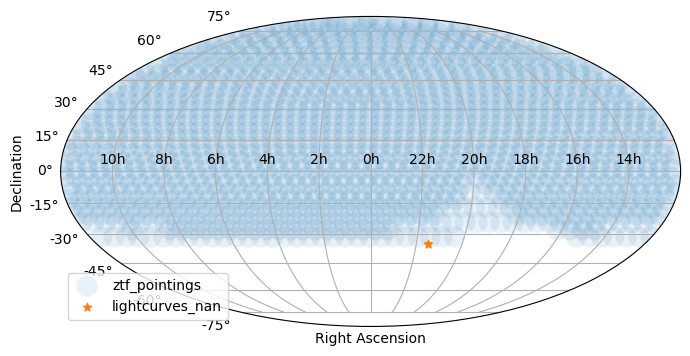

In [19]:
plot_coverage_map(ztf_obstable,lightcurves,plot_na_location=True,plot_all_location=False)

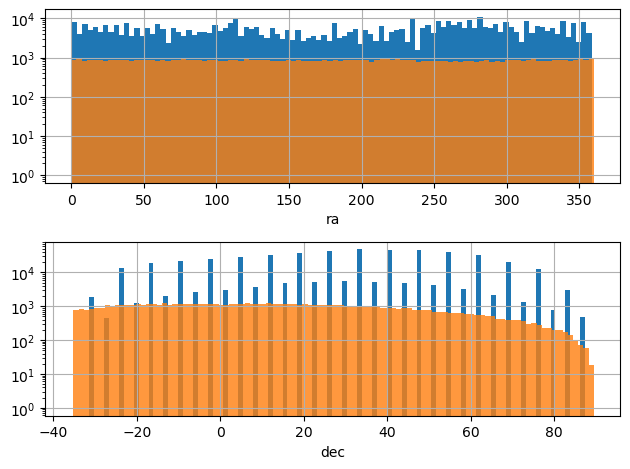

In [20]:
idx = lightcurves.lightcurve.isna()

plt.subplot(2,1,1)
ztf_obstable._table.ra.hist(bins=100,density=False)
lightcurves.ra.hist(bins=100,alpha=0.8,density=False)
lightcurves.loc[idx].ra.hist(bins=100)
plt.yscale('log')
plt.xlabel('ra')

plt.subplot(2,1,2)
ztf_obstable._table.dec.hist(bins=100,density=False)
lightcurves.dec.hist(bins=100,alpha=0.8,density=False)
lightcurves.loc[idx].dec.hist(bins=100)
plt.yscale('log')
plt.xlabel('dec')

plt.tight_layout()

In [21]:
# calculate detection flag
lightcurves = lightcurves.dropna(subset=['lightcurve'])

print("Before applying detection: nsn=", len(lightcurves))
lightcurves['lightcurve.snr'] = lightcurves['lightcurve.flux']/lightcurves['lightcurve.fluxerr']
detection_snr_thres = 5.
lightcurves['lightcurve.detection_flag'] = lightcurves['lightcurve.snr'] > detection_snr_thres

# drop saturation
lightcurves_after_drop_sat = lightcurves.query("lightcurve.is_saturated==False").dropna(subset=['lightcurve'])
print("After droppoing saturation: nsn=", len(lightcurves_after_drop_sat))

lightcurves_after_detection = lightcurves_after_drop_sat.query("lightcurve.detection_flag == True").dropna(subset=['lightcurve'])
print("After applying detection: nsn=", len(lightcurves_after_detection))

Before applying detection: nsn= 84687


/Users/mi/anaconda3/envs/lightcurvelynx/lib/python3.11/site-packages/nested_pandas/nestedframe/core.py:321: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return super().__setitem__(nested, new_nested_series)
/Users/mi/anaconda3/envs/lightcurvelynx/lib/python3.11/site-packages/nested_pandas/nestedframe/core.py:321: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return super().__setitem__(nested, new_nested_series)
/Users/mi/anaconda3/envs/lightcurvelynx/lib/python3.11/site-packages/nested_pandas/nestedframe/c

After droppoing saturation: nsn= 84687


/Users/mi/anaconda3/envs/lightcurvelynx/lib/python3.11/site-packages/nested_pandas/nestedframe/core.py:1352: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  answer = super().eval(expr, **kwargs)


After applying detection: nsn= 43303


ZTF Selection Function (Fig 4 of ZTF DR2 Overview paper https://arxiv.org/pdf/2409.04346)
<img src="figs/ztf_selection_function.png" width="800" height="400">
<img src="figs/ztf_selection_function_formulism.png" width="800" height="400">

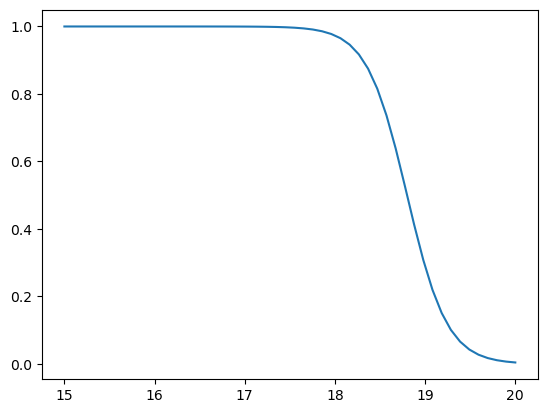

In [22]:
m = np.linspace(15,20,50)
m0=18.8
s=4.5
p = np.power(1. + np.exp((m - m0)*s), -1)
plt.plot(m,p)

In [23]:
# The selection function is defined as below.
display(Markdown(f"```python\n{inspect.getsource(spec_selection_func)}\n```"))

```python
def spec_selection_func(flux,p0=None,m0=18.8,s=4.5):
    if p0 is None:
        p0 = np.random.uniform(0,1)
    m = flux2mag(np.max(flux))
    p = np.power(1. + np.exp((m - m0)*s), -1)
    return {"pass_spec_selection": p0 < p}

```

In [24]:
# apply the above selection function
rng = np.random.default_rng(RANDSEED)
p0 = rng.uniform(0,1,lightcurves_after_detection["id"].max()+1)
def spec_selection_func_p0(flux, index, p0=p0):
    return spec_selection_func(flux, p0=p0[index])

pass_selection = lightcurves_after_detection.reduce(spec_selection_func_p0,"lightcurve.flux","id")
idx = pass_selection.query("pass_spec_selection == True").index
lightcurves_after_spec_selection = lightcurves_after_detection.loc[idx]
print("After spectroscopic selection: nsn=", len(lightcurves_after_spec_selection))

lightcurves["pass_spec_selection"] = False
lightcurves.loc[idx,"pass_spec_selection"] = True

/var/folders/zs/zxl3t6ks12zg2l3dp9qn1rkr0000gn/T/ipykernel_3392/2493765723.py:7: DeprecationWarning: Call to deprecated method reduce. (`reduce` will be removed in version 0.7.0, use `map_rows` instead.) -- Deprecated since version 0.6.0.
  pass_selection = lightcurves_after_detection.reduce(spec_selection_func_p0,"lightcurve.flux","id")


After spectroscopic selection: nsn= 4313


/Users/mi/anaconda3/envs/lightcurvelynx/lib/python3.11/site-packages/nested_pandas/nestedframe/core.py:334: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [25]:
## ZTF SN DR2 selection cuts
# Start 3795
# No ZTF light curve -17 = 3778
# No spectra -110 = 3668
# No confirmed Ia type from spectra -40 = 3628
# Good sampling (7 different phases, 2 before, 2 after peak, 2 bands) = 2960, peak based on a salt2 fit
# SALT2 cuts = 2667

#### ZTF SN DR2 selection cuts
<img src="figs/ztf_selection_Table1_Rigault2024.png" width="800" height="400">

#### Good sampling cuts
<img src="figs/good_sample_cut.png" width="600" height="200">
<img src="figs/good_sample_cut2.png" width="600" height="200">

In [26]:
# The lc_quality_cuts is defined as below
display(Markdown(f"```python\n{inspect.getsource(lc_quality_cuts)}\n```"))

```python
def lc_quality_cuts(flux,mjd,filter,z,n_phases=7, n_before_peak=2, n_after_peak=2, n_bands=2):
    peak_idx = np.argmax(flux)
    phases = np.floor((mjd - mjd[peak_idx])/(1. + z))
    unique_phases,unique_idx = np.unique(phases,return_index=True)
    good_idx = (unique_phases >= -10) & (unique_phases<=40)
    pass_cut = len(unique_phases[good_idx]) >= n_phases
    flux_new = flux[unique_idx][good_idx]
    peak_idx_new = np.argmax(flux_new)
    pass_cut &= (peak_idx_new >= n_before_peak - 1) & (len(flux_new) - peak_idx_new >= n_after_peak - 1)
    pass_cut &= len(np.unique(filter[unique_idx][good_idx])) >= n_bands
    return {"pass_quality_cuts": pass_cut}

```

In [27]:
pass_quality_cut = lightcurves_after_spec_selection.reduce(lc_quality_cuts,"lightcurve.flux",
                                                           "lightcurve.mjd","lightcurve.filter","z")
idx = pass_quality_cut.query("pass_quality_cuts == True").index
lightcurves_after_quality_cut = lightcurves_after_spec_selection.loc[idx]
print("After quality cuts: nsn=", len(lightcurves_after_quality_cut))

lightcurves["pass_quality_cuts"] = False
lightcurves.loc[idx,"pass_quality_cuts"] = True

After quality cuts: nsn= 3346


/var/folders/zs/zxl3t6ks12zg2l3dp9qn1rkr0000gn/T/ipykernel_3392/2223098793.py:1: DeprecationWarning: Call to deprecated method reduce. (`reduce` will be removed in version 0.7.0, use `map_rows` instead.) -- Deprecated since version 0.6.0.
  pass_quality_cut = lightcurves_after_spec_selection.reduce(lc_quality_cuts,"lightcurve.flux",
/Users/mi/anaconda3/envs/lightcurvelynx/lib/python3.11/site-packages/nested_pandas/nestedframe/core.py:334: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [28]:
lightcurves.head()

id          ra        dec  nobs            t0         z  \
0   0  127.978813  23.512839   741  58461.402165  0.074747   
1   1  304.858738  69.527167   854  58994.257449  0.191377   
2   2  193.177977 -16.186343   156  58348.346806  0.146783   
3   3  231.913841 -18.901383   152  58464.224007  0.114567   
4   4  355.032567 -33.498347    51  58786.375942  0.173284   

                                              params  source_x0  source_x1  \
0  {'radec.ra': 127.97891133627752, 'radec.dec': ...   0.000318  -0.164099   
1  {'radec.ra': 304.8591053296168, 'radec.dec': 6...   0.000004  -3.560757   
2  {'radec.ra': 193.17845040105993, 'radec.dec': ...   0.000017  -2.095448   
3  {'radec.ra': 231.9141700613855, 'radec.dec': -...   0.000240   0.335408   
4  {'radec.ra': 355.0325435268815, 'radec.dec': -...   0.000058  -2.172132   

   source_c  host_hostmass   source_ra  source_dec     host_ra   host_dec  \
0  0.338181       9.323363  127.978813   23.512839  127.978911  23.512796   
1  0.866296      10.776040  304.858738   69.527167  304.859105  69.527140   
2  0.742912       9.723345  193.177977  -16.186343  193.178450 -16.186387   
3  0.066992      10.234649  231.913841  -18.901383  231.914170 -18.900816   
4  0.119945      10.508610  355.032567  -33.498347  355.032544 -33.498356   

                                          lightcurve  pass_spec_selection  \
0  [{mjd: 58369.523438, filter: 'r', flux: 18247....                 True   
1  [{mjd: 58290.386719, filter: 'r', flux: -103.3...                False   
2  [{mjd: 58289.175781, filter: 'g', flux: -407.1...                False   
3  [{mjd: 58289.230469, filter: 'r', flux: -6890....                False   
4  [{mjd: 59106.292969, filter: 'g', flux: 8418.9...                False   

   pass_quality_cuts  
0               True  
1              False  
2              False  
3              False  
4              False

In [29]:
#saving to parquet file
lightcurves.to_parquet("results/lightcurves.parquet")

In [30]:
def fit_single_lc_w_cond(lc,
                         bounds={"x1": (-5,5),
                                 "c": (-0.4,1),},
                         phase_range=(-10,40),
                         modelcov=False):
    return fit_single_lc(lc,mpbounds=bounds,phase_range=phase_range,modelcov=modelcov)

In [31]:
res = fit_single_lc_w_cond(lightcurves_after_quality_cut.iloc[0])
res

INFO:utils.lcfit:fitting 0, z=0.07474734537373094, mwebv=0.02893089369146721.


success       1.0
ncall        52.0
             ... 
id            0.0
fit_error     NaN
Length: 54, dtype: float64

In [32]:
lc_to_fit = lightcurves_after_quality_cut.iloc[0:]

In [33]:
# %%time
# result_df0 = lc_to_fit.apply(fit_single_lc,axis=1)

In [34]:
%%time
results = Parallel(n_jobs=10)(delayed(fit_single_lc_w_cond)(row) for _index, row in lc_to_fit.iterrows())
result_df = pd.DataFrame(results)

CPU times: user 5.98 s, sys: 856 ms, total: 6.83 s
Wall time: 1min 21s


In [35]:
result_df = result_df.set_index('id')

In [36]:
result_df.dropna(subset=['success'])

,success,ncall,chisq,ndof,z,z_err,t0,t0_err,x0,x0_err,...,c_x1_cov,c_c_cov,c_mwebv_cov,mwebv_z_cov,mwebv_t0_cov,mwebv_x0_cov,mwebv_x1_cov,mwebv_c_cov,mwebv_mwebv_cov,fit_error
id,,,,,,,,,,,,,,,,,,,,,
0.0,1.0,52.0,21.983015,14.0,0.074747,0.0,58461.561800,0.235738,0.000314,0.000007,...,-0.001524,0.000488,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
23.0,1.0,94.0,148.896177,131.0,0.032862,0.0,59103.807053,0.016193,0.002300,0.000006,...,0.000009,0.000005,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84634.0,1.0,95.0,40.942260,38.0,0.021808,0.0,59122.081714,0.030881,0.003159,0.000030,...,0.000183,0.000043,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
84666.0,1.0,60.0,88.949936,79.0,0.095523,0.0,58536.906089,0.650625,0.000375,0.000009,...,-0.001650,0.000260,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN


In [37]:
result_df.to_csv('results/salt3fit_results.csv')